In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy import stats
import pingouin as pg
import numpy as np

In [2]:
ndvi_path = '/Users/tillweiss/Desktop/MODSNOW/MODSNOW_irrigated_MarJul_2000_2024/MOD13Q1-061-Statistics.csv'
snow_path = '/Users/tillweiss/Desktop/MODSNOW/data/cloud_snow_fraction_amudarya_kerky_4report.txt'

In [5]:
ndvi = pd.read_csv(ndvi_path)

ndvi['Date'] = pd.to_datetime(ndvi['Date'])
ndvi = ndvi[['Date', 'Mean']]
ndvi = ndvi.rename(columns={'Mean': 'NDVI'})

In [18]:
ndvi

,Date,NDVI
0,2000-02-18,0.100339
1,2000-03-05,0.104449
2,2000-03-21,0.115389
3,2000-04-06,0.149180
4,2000-04-22,0.203452
...,...,...
583,2025-06-26,0.316781
584,2025-07-12,0.343874
585,2025-07-28,0.358984
586,2025-08-13,0.356911


In [6]:
snow = pd.read_csv(snow_path,
    sep=';',
    header=None,
    engine='python'
)

snow.columns = ['Year', 'Day', 'Snow_Mean', 'Snow_Percent','nn']
snow['Snow_Mean'] = snow['Snow_Mean'].replace(-9, pd.NA)

snow['Date'] = pd.to_datetime(
    snow['Year'].astype(int).astype(str),
    format='%Y'
) + pd.to_timedelta(snow['Day'] - 1, unit='D')

snow = snow[['Date', 'Snow_Percent']]
snow

,Date,Snow_Percent
0,2000-02-26,54.58
1,2000-02-27,55.93
2,2000-02-28,56.73
3,2000-02-29,56.78
4,2000-03-01,56.29
...,...,...
9245,2025-06-20,6.18
9246,2025-06-21,8.12
9247,2025-06-22,5.59
9248,2025-06-23,6.48


In [7]:
ndvi_daily = ndvi[['Date', 'NDVI']].set_index('Date').resample('D').asfreq()
snow_daily = snow[['Date', 'Snow_Percent']].set_index('Date').resample('D').asfreq()

snow_ndvi_d = ndvi_daily.join(snow_daily, how='left')
snow_ndvi_d = snow_ndvi_d[snow_ndvi_d.index.month.isin([3, 4, 5, 6, 7, 8, 9])]


In [8]:
snow_16d = []

ndvi_dates = snow_ndvi_d.index[snow_ndvi_d['NDVI'].notna()]

for d in ndvi_dates:
    window = snow_ndvi_d.loc[d : d + pd.Timedelta(days=15), 'Snow_Percent']
    snow_16d.append(window.mean())

snow_ndvi_d.loc[ndvi_dates, 'Snow_16d'] = snow_16d
snow_ndvi_d = snow_ndvi_d.reset_index()  


In [7]:
snow_ndvi_d

,Date,NDVI,Snow_Percent,Snow_16d
0,2000-03-01,NaN,56.29,NaN
1,2000-03-02,NaN,56.54,NaN
2,2000-03-03,NaN,57.37,NaN
3,2000-03-04,NaN,59.48,NaN
4,2000-03-05,0.104449,66.54,53.3825
...,...,...,...,...
5527,2025-08-25,NaN,NaN,NaN
5528,2025-08-26,NaN,NaN,NaN
5529,2025-08-27,NaN,NaN,NaN
5530,2025-08-28,NaN,NaN,NaN


In [9]:
ndvi_snow = snow_ndvi_d.copy()
ndvi_snow['Month'] = snow_ndvi_d['Date'].dt.month
ndvi_snow['Year'] = snow_ndvi_d['Date'].dt.year

#ndvi_snow = ndvi_snow[ndvi_snow['NDVI'] >= 0.2] Correlatino decrases excluding low values 

ndvi_snow = ndvi_snow.dropna()

ndvi_snow

,Date,NDVI,Snow_Percent,Snow_16d,Month,Year
4,2000-03-05,0.104449,66.54,53.382500,3,2000
20,2000-03-21,0.115389,47.06,43.998750,3,2000
36,2000-04-06,0.149180,40.63,33.395625,4,2000
52,2000-04-22,0.203452,24.56,24.993125,4,2000
68,2000-05-08,0.225870,16.48,13.888750,5,2000
...,...,...,...,...,...,...
5387,2025-04-07,0.202731,38.61,24.251250,4,2025
5403,2025-04-23,0.239482,34.29,26.625625,4,2025
5419,2025-05-09,0.262869,19.75,9.014375,5,2025
5435,2025-05-25,0.275582,13.26,11.900625,5,2025


In [9]:
snow_data = pd.DataFrame(ndvi_snow, columns=['Date', 'Snow_Percent', 'Snow_16d'])
snow_data.to_csv('/Users/tillweiss/Desktop/MODSNOW/data/snow_agg.csv', index=False)

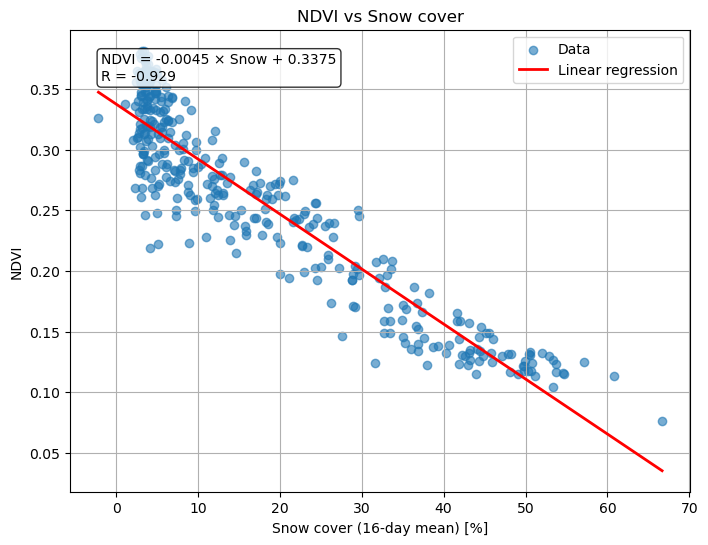

Pearson correlation: -0.929, p-value = 5.484e-155
Spearman correlation: -0.893, p-value = 4.373e-125
Regression slope: -0.0045
Regression intercept: 0.3375
Regression p-value: 5.484e-155


In [ ]:
df_corr = ndvi_snow[['NDVI', 'Snow_16d']].dropna()

x = df_corr['Snow_16d']
y = df_corr['NDVI']

slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

x_fit = np.linspace(x.min(), x.max(), 100)
y_fit = intercept + slope * x_fit

plt.figure(figsize=(8,6))
plt.scatter(x, y, alpha=0.6, label='Data')
plt.plot(x_fit, y_fit, color='red', linewidth=2, label='Linear regression')

plt.xlabel('Snow cover (16-day mean) [%]')
plt.ylabel('NDVI')
plt.title('NDVI vs Snow cover')
plt.grid(True)

plt.text(
    0.05, 0.95,
    f'NDVI = {slope:.4f} × Snow + {intercept:.4f}\n'
    f'R = {r_value:.3f}',
    transform=plt.gca().transAxes,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)

plt.legend()
plt.show()

pearson_coef, pearson_p = stats.pearsonr(x, y)
spearman_coef, spearman_p = stats.spearmanr(x, y)

print(f'Pearson correlation: {pearson_coef:.3f}, p-value = {pearson_p:.3e}')
print(f'Spearman correlation: {spearman_coef:.3f}, p-value = {spearman_p:.3e}')

print(f'Regression slope: {slope:.4f}')
print(f'Regression intercept: {intercept:.4f}')
print(f'Regression p-value: {p_value:.3e}')

- Looking at 16 day NDVI and correspoding snow coverage shows strong negative correlation
- High snow coaverage -> low NDVI
- But looking at snow mean over 16 days here corresponding to NDVI
- Including all snow values, includes seasonal trend

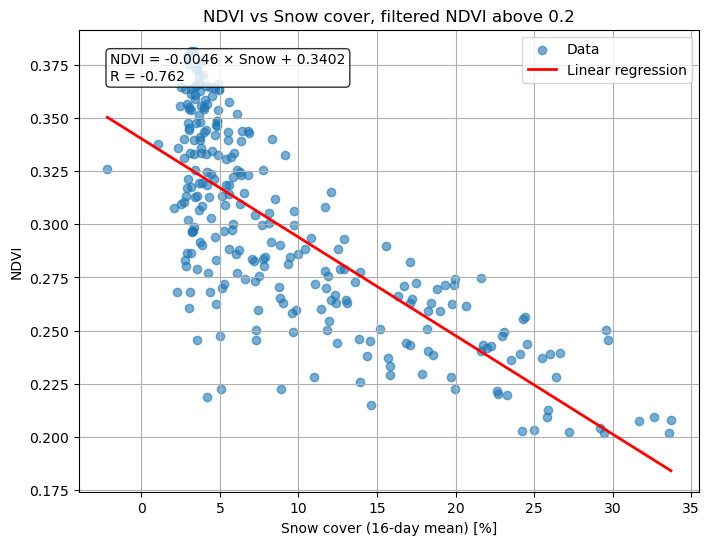

Pearson correlation: -0.762, p-value = 1.400e-51
Spearman correlation: -0.750, p-value = 4.798e-49
Regression slope: -0.0046
Regression intercept: 0.3402
Regression p-value: 1.400e-51


In [24]:
df_corr = ndvi_snow[['NDVI', 'Snow_16d']].dropna()

df_corr = df_corr[df_corr['NDVI'] >= 0.2]

x = df_corr['Snow_16d']
y = df_corr['NDVI']

slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

x_fit = np.linspace(x.min(), x.max(), 100)
y_fit = intercept + slope * x_fit

plt.figure(figsize=(8,6))
plt.scatter(x, y, alpha=0.6, label='Data')
plt.plot(x_fit, y_fit, color='red', linewidth=2, label='Linear regression')

plt.xlabel('Snow cover (16-day mean) [%]')
plt.ylabel('NDVI')
plt.title('NDVI vs Snow cover, filtered NDVI above 0.2')
plt.grid(True)

plt.text(
    0.05, 0.95,
    f'NDVI = {slope:.4f} × Snow + {intercept:.4f}\n'
    f'R = {r_value:.3f}',
    transform=plt.gca().transAxes,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)

plt.legend()
plt.show()

pearson_coef, pearson_p = stats.pearsonr(x, y)
spearman_coef, spearman_p = stats.spearmanr(x, y)

print(f'Pearson correlation: {pearson_coef:.3f}, p-value = {pearson_p:.3e}')
print(f'Spearman correlation: {spearman_coef:.3f}, p-value = {spearman_p:.3e}')

print(f'Regression slope: {slope:.4f}')
print(f'Regression intercept: {intercept:.4f}')
print(f'Regression p-value: {p_value:.3e}')


In [11]:
march_snow = (
    ndvi_snow[ndvi_snow['Month'] == 3]
    .groupby(['Year', 'Month'])['Snow_Percent']
    .mean()
    .reset_index()
    .rename(columns={'Snow_Percent': 'March_Snow'})
    .drop(columns='Month')
)

months = [3, 4, 5, 6, 7, 8]
month_names = ['March', 'April', 'May', 'June', 'July', 'August']

- Averageing snow values for march of each year

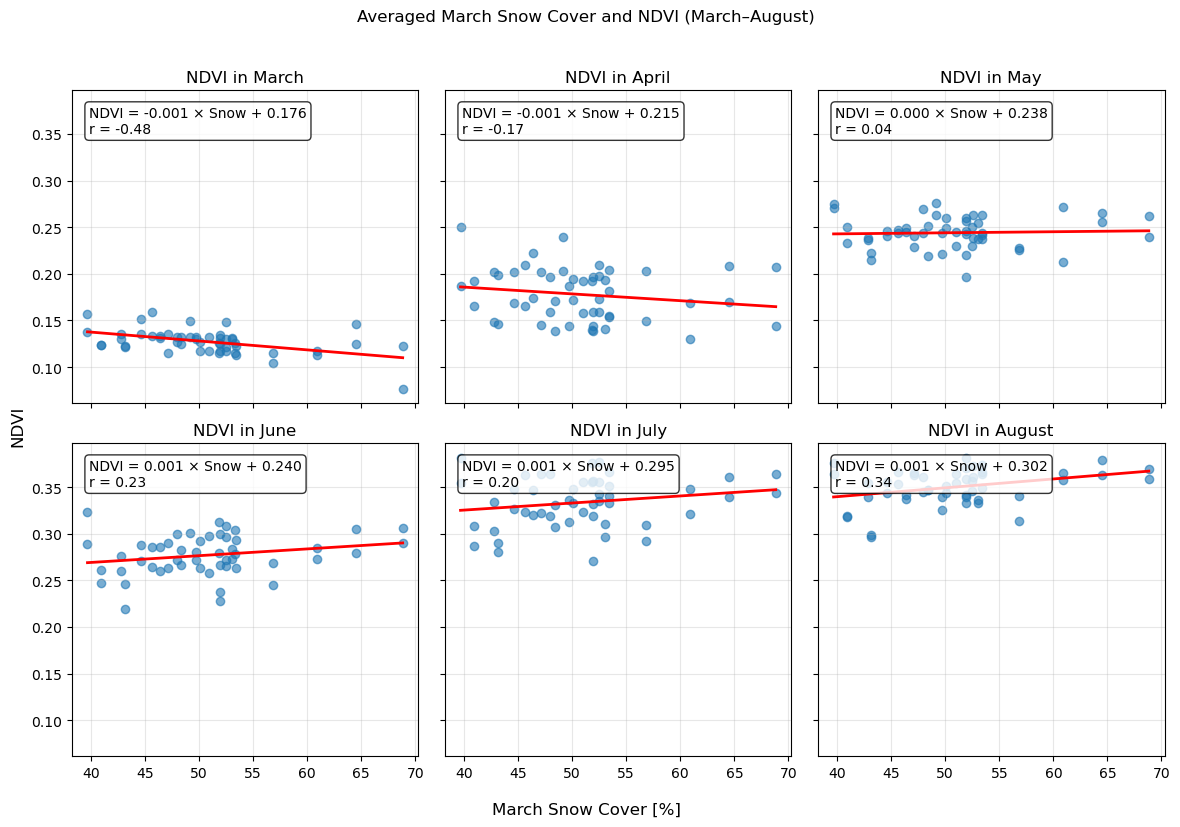

In [145]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.flatten()

for ax, m, name in zip(axes, months, month_names):

    ndvi_m = ndvi_snow[ndvi_snow['Month'] == m]

    aligned = march_snow.merge(ndvi_m, on='Year', how='inner')

    x = aligned['March_Snow']
    y = aligned['NDVI']

    # Scatter
    ax.scatter(x, y, alpha=0.6)

    # Only fit regression if enough points
    if len(aligned) >= 3:
        slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

        x_fit = np.linspace(x.min(), x.max(), 100)
        y_fit = intercept + slope * x_fit

        ax.plot(x_fit, y_fit, linewidth=2, color='r')

        ax.text(
            0.05, 0.95,
            f'NDVI = {slope:.3f} × Snow + {intercept:.3f}\n'
            f'r = {r_value:.2f}',
            transform=ax.transAxes,
            va='top', ha='left',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
        )
    else:
        ax.text(
            0.05, 0.95,
            'n < 3',
            transform=ax.transAxes,
            va='top', ha='left'
        )

    ax.set_title(f'NDVI in {name}')
    ax.grid(True, alpha=0.3)

fig.supxlabel('March Snow Cover [%]')
fig.supylabel('NDVI')
fig.suptitle('Averaged March Snow Cover and NDVI (March–August)', y=1.02)

plt.tight_layout()
plt.show()


Compares the averged march snow cover over 30 days to NDVI (2x per month)

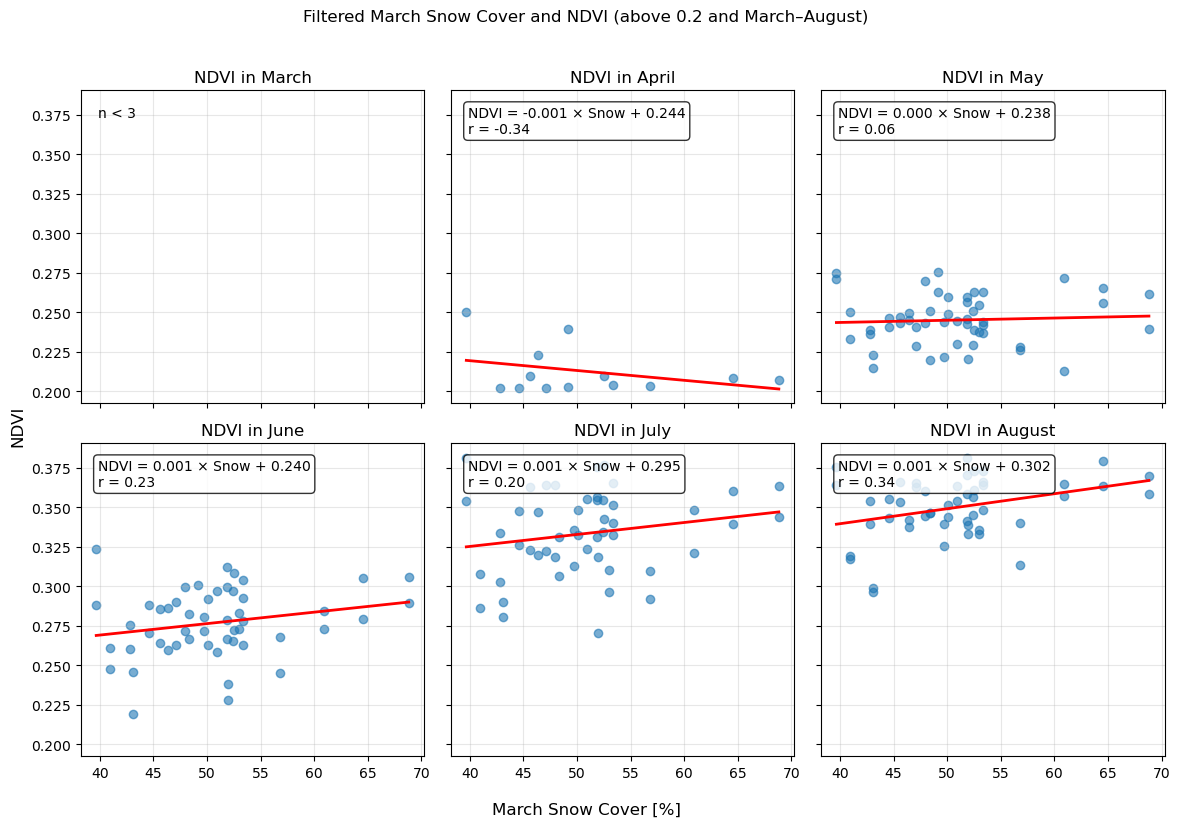

In [144]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.flatten()

for ax, m, name in zip(axes, months, month_names):

    ndvi_m = (
        ndvi_snow[ndvi_snow['Month'] == m]
    )
    ndvi_m = ndvi_m[ndvi_m['NDVI'] >= 0.2]

    aligned = march_snow.merge(ndvi_m, on='Year', how='inner')

    x = aligned['March_Snow']
    y = aligned['NDVI']

    # Scatter plot
    ax.scatter(x, y, alpha=0.6)

    # Regression (only if enough data)
    if len(aligned) >= 3:
        slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

        x_fit = np.linspace(x.min(), x.max(), 100)
        y_fit = intercept + slope * x_fit

        ax.plot(x_fit, y_fit, linewidth=2, color='r')

        ax.text(
            0.05, 0.95,
            f'NDVI = {slope:.3f} × Snow + {intercept:.3f}\n'
            f'r = {r_value:.2f}',
            transform=ax.transAxes,
            va='top', ha='left',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
        )
    else:
        ax.text(
            0.05, 0.95,
            'n < 3',
            transform=ax.transAxes,
            va='top', ha='left'
        )

    ax.set_title(f'NDVI in {name}')
    ax.grid(True, alpha=0.3)

fig.supxlabel('March Snow Cover [%]')
fig.supylabel('NDVI')
fig.suptitle('Filtered March Snow Cover and NDVI (above 0.2 and March–August)', y=1.02)

plt.tight_layout()
plt.show()


Introduces as thershold .2 to filter out low ndvi pixel

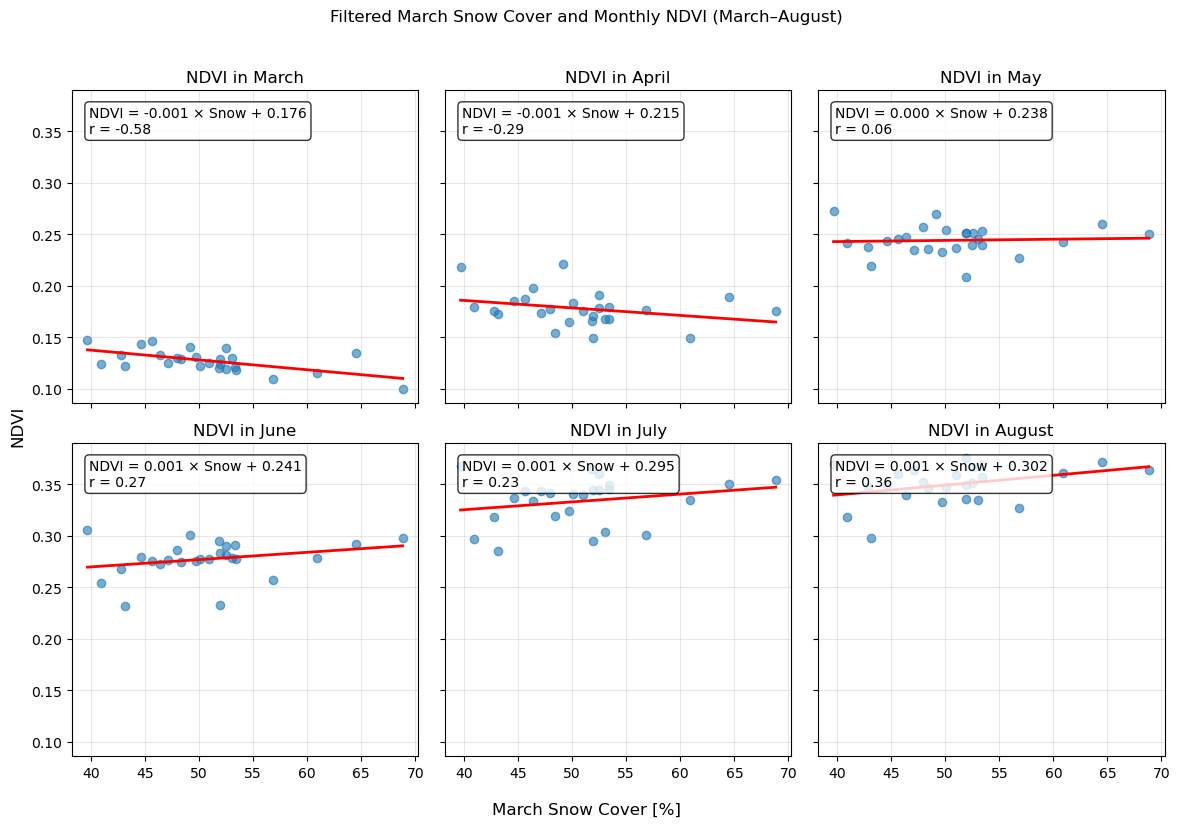

In [146]:
ndvi_monthly = (
    ndvi_snow
    .groupby(['Year', 'Month'], as_index=False)
    .agg(NDVI=('NDVI', 'mean'))  
)

fig, axes = plt.subplots(2, 3, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.flatten()

for ax, m, name in zip(axes, months, month_names):

    ndvi_m = ndvi_monthly[ndvi_monthly['Month'] == m].copy()
    #ndvi_m = ndvi_m[ndvi_m['NDVI'] >= 0.2]

    aligned = march_snow.merge(ndvi_m, on='Year', how='inner')

    x = aligned['March_Snow']
    y = aligned['NDVI']

    ax.scatter(x, y, alpha=0.6)

    if len(aligned) >= 3:
        slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

        x_fit = np.linspace(x.min(), x.max(), 100)
        y_fit = intercept + slope * x_fit

        ax.plot(x_fit, y_fit, linewidth=2, color='r')

        ax.text(
            0.05, 0.95,
            f'NDVI = {slope:.3f} × Snow + {intercept:.3f}\n'
            f'r = {r_value:.2f}',
            transform=ax.transAxes,
            va='top', ha='left',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
        )
    else:
        ax.text(
            0.05, 0.95,
            'n < 3',
            transform=ax.transAxes,
            va='top', ha='left'
        )

    ax.set_title(f'NDVI in {name}')
    ax.grid(True, alpha=0.3)

fig.supxlabel('March Snow Cover [%]')
fig.supylabel('NDVI')
fig.suptitle('Filtered March Snow Cover and Monthly NDVI (March–August)', y=1.02)

plt.tight_layout()
plt.show()


Compares mean march sca to monthly ndvi 

In [65]:
df = ndvi_snow[~((ndvi_snow['Date'].dt.month == 2) & (ndvi_snow['Date'].dt.day == 29))]

df['DOY'] = df['Date'].dt.dayofyear

df

,Date,NDVI,Snow_Percent,Snow_16d,Month,Year,DOY
4,2000-03-05,0.104449,66.54,53.382500,3,2000,65
20,2000-03-21,0.115389,47.06,43.998750,3,2000,81
36,2000-04-06,0.149180,40.63,33.395625,4,2000,97
52,2000-04-22,0.203452,24.56,24.993125,4,2000,113
68,2000-05-08,0.225870,16.48,13.888750,5,2000,129
...,...,...,...,...,...,...,...
5387,2025-04-07,0.202731,38.61,24.251250,4,2025,97
5403,2025-04-23,0.239482,34.29,26.625625,4,2025,113
5419,2025-05-09,0.262869,19.75,9.014375,5,2025,129
5435,2025-05-25,0.275582,13.26,11.900625,5,2025,145


In [95]:
ndvi_wide = df.pivot(index='Year', columns='DOY', values='NDVI')
snow_wide = df.pivot(index='Year', columns='DOY', values='Snow_16d')

In [101]:
corr_matrix = pd.DataFrame(
    index=ndvi_wide.columns,
    columns=snow_wide.columns,
    dtype=float
)

for ndvi_doy in ndvi_wide.columns:
    for snow_doy in snow_wide.columns:
        x = ndvi_wide[ndvi_doy]
        y = snow_wide[snow_doy]

        valid = x.notna() & y.notna()

        if valid.sum() >= 5:   # minimum years
            corr_matrix.loc[ndvi_doy, snow_doy] = x[valid].corr(y[valid])
        else:
            corr_matrix.loc[ndvi_doy, snow_doy] = np.nan


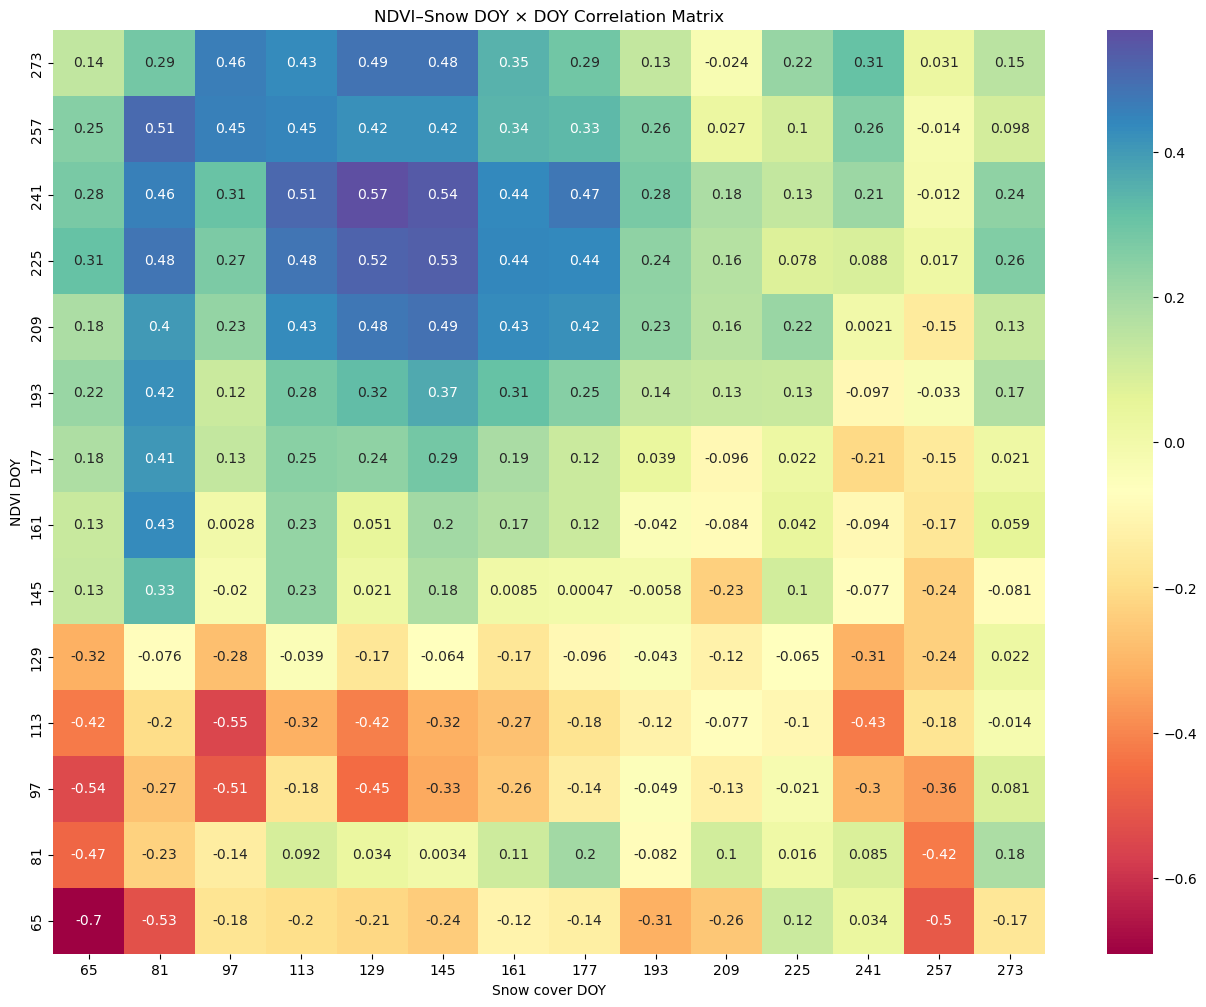

In [143]:
import seaborn as sns

plt.figure(figsize=(16,12))
sns.heatmap(corr_matrix, annot=True, cmap='Spectral').invert_yaxis()

plt.xlabel('Snow cover DOY')
plt.ylabel('NDVI DOY')
plt.title('NDVI–Snow DOY × DOY Correlation Matrix')
plt.show()

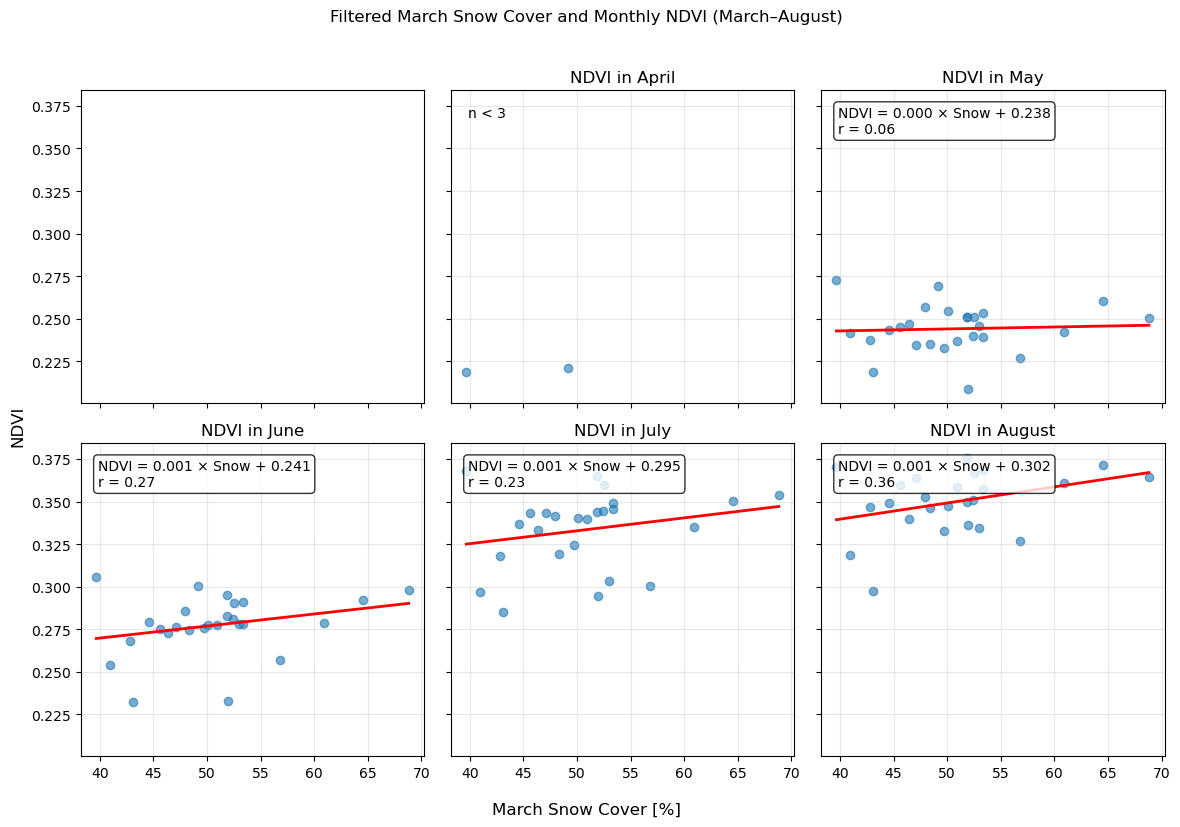

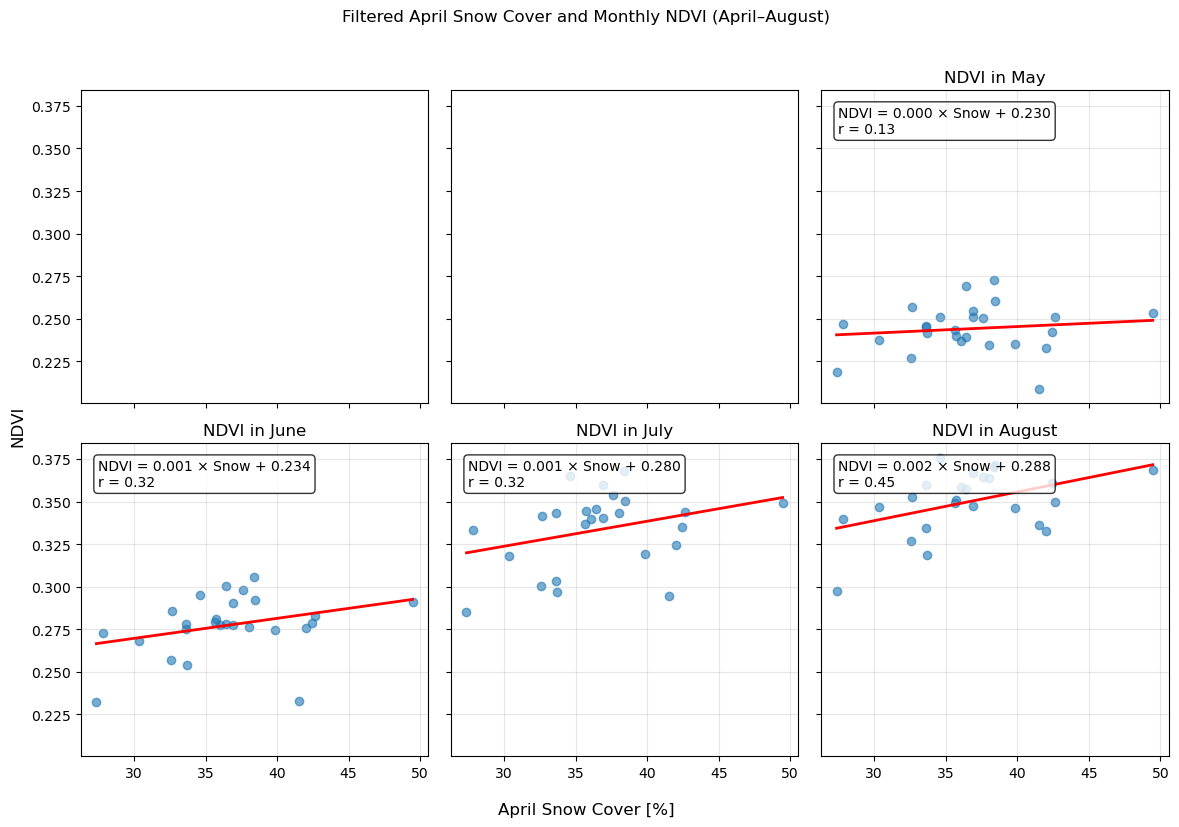

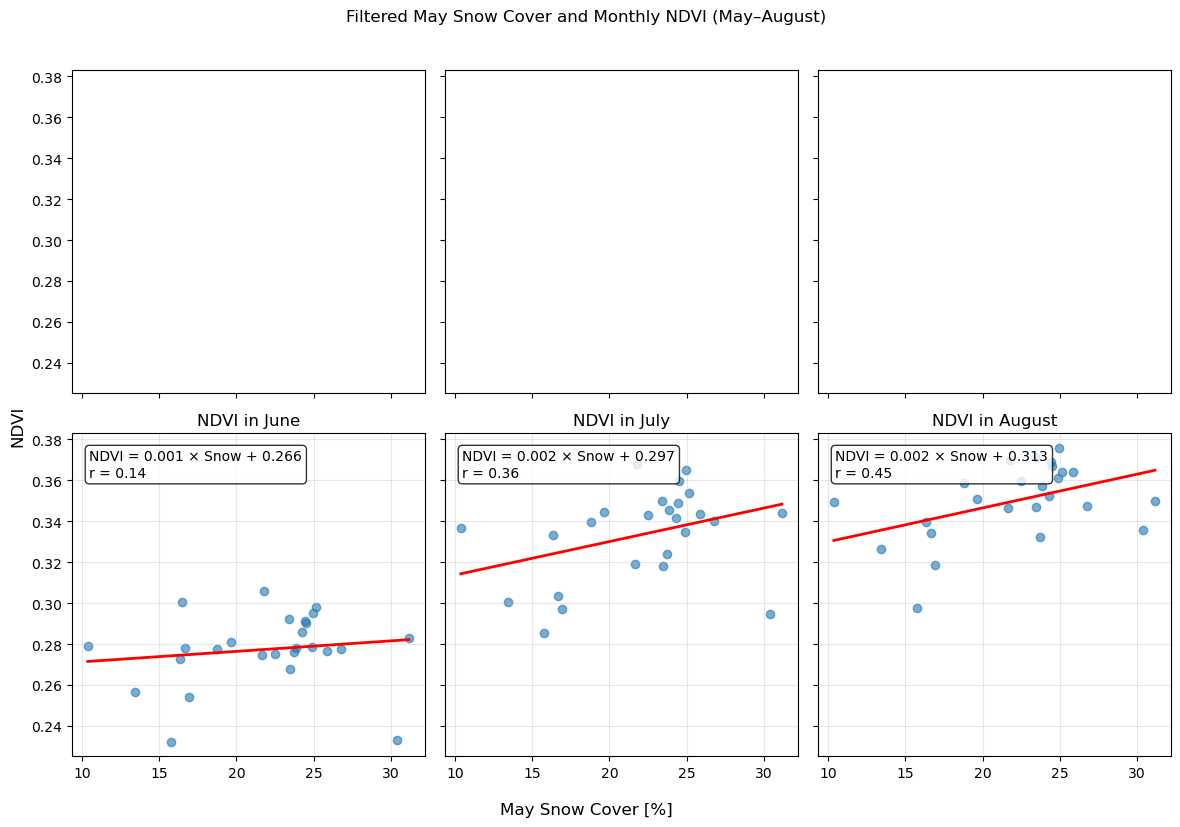

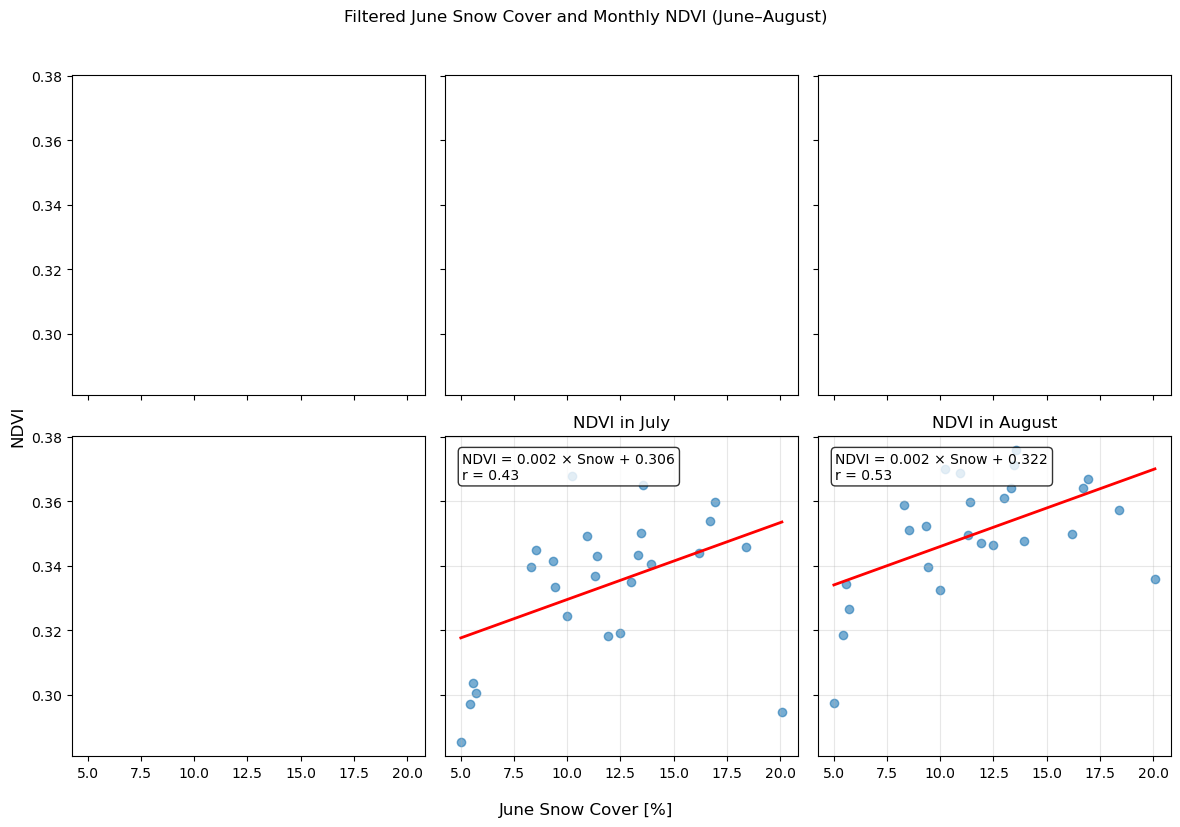

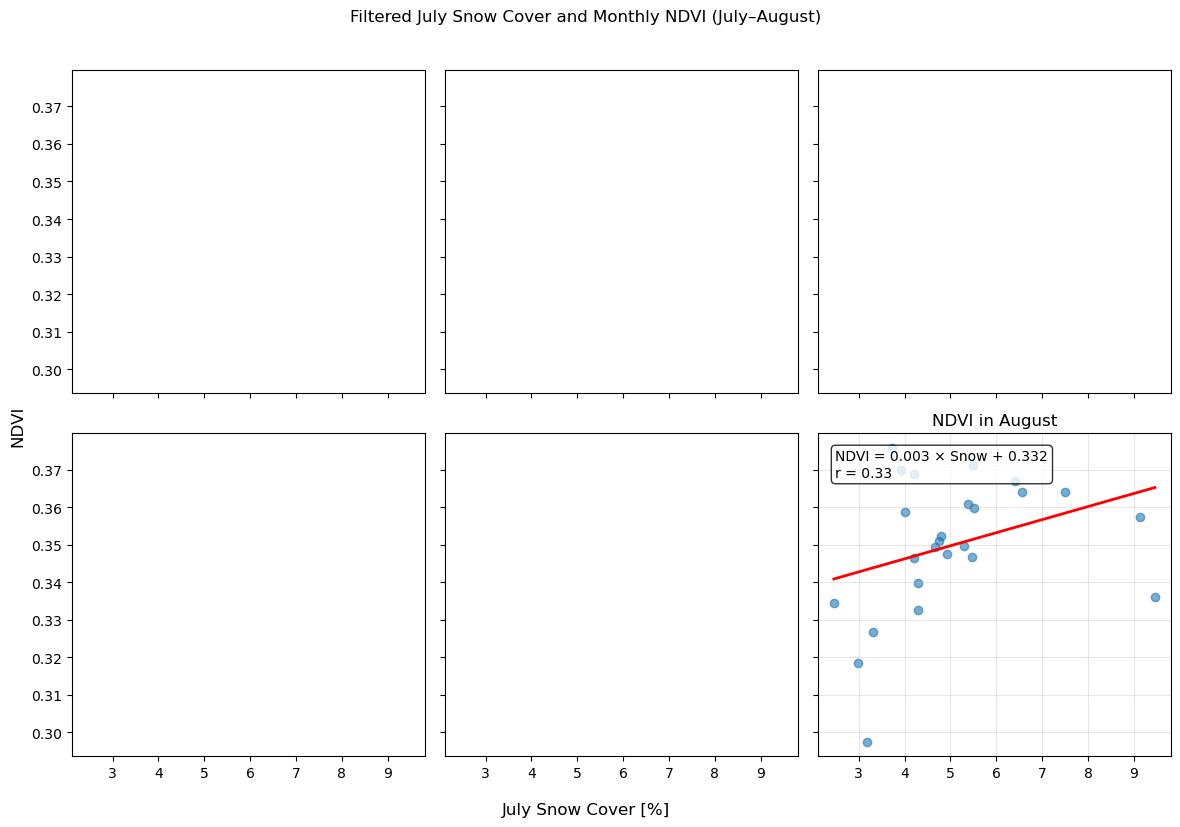

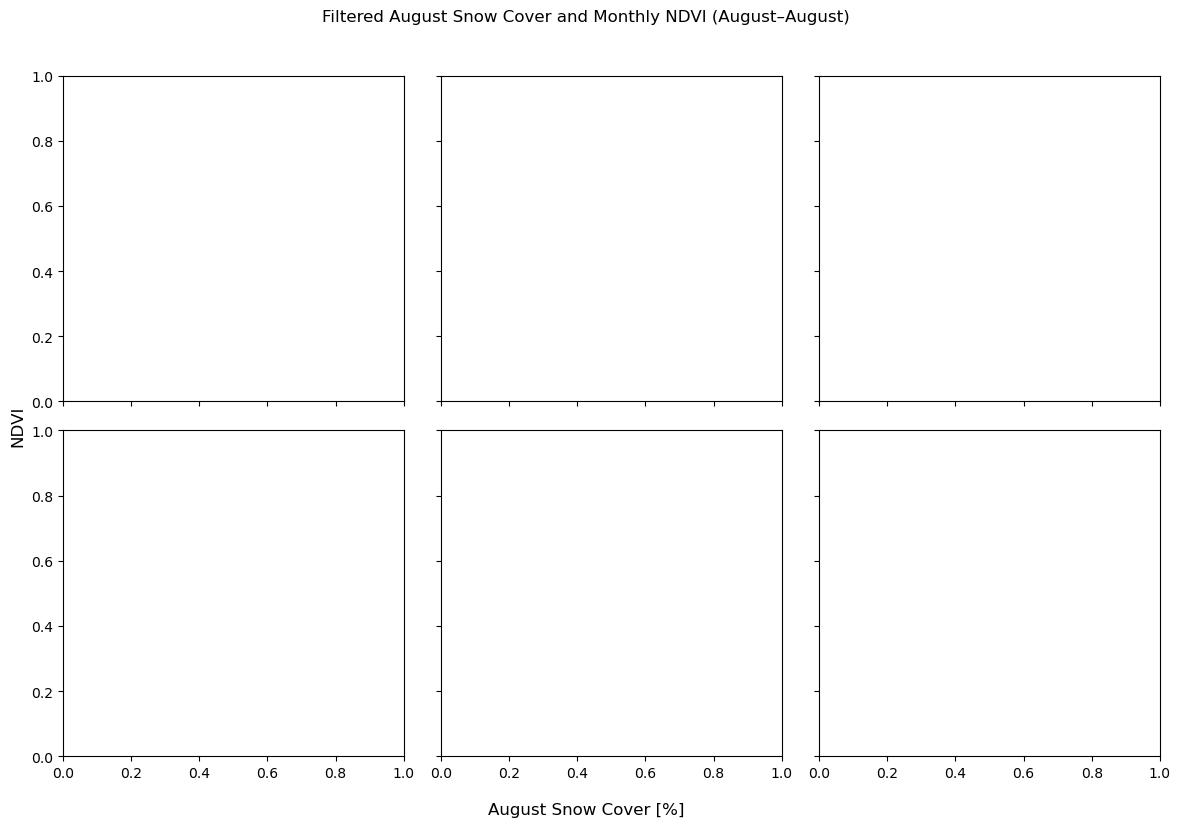

In [17]:
months = [3, 4, 5, 6, 7, 8]
month_names = ['March', 'April', 'May', 'June', 'July', 'August']

ndvi_monthly = (
    ndvi_snow
    .groupby(['Year', 'Month'], as_index=False)
    .agg(NDVI=('NDVI', 'mean'))  
)

for i, n in zip(months, month_names):

    month_snow = (
    ndvi_snow[ndvi_snow['Month'] == i]
    .groupby(['Year', 'Month'])['Snow_Percent']
    .mean()
    .reset_index()
    .rename(columns={'Snow_Percent': f'{n}_Snow'})
    .drop(columns='Month')
    )

    fig, axes = plt.subplots(2, 3, figsize=(12, 8), sharex=True, sharey=True)
    axes = axes.flatten()

    for ax, m, name in zip(axes, months, month_names):

        if m <= i:
            continue

        ndvi_m = ndvi_monthly[ndvi_monthly['Month'] == m].copy()
        ndvi_m = ndvi_m[ndvi_m['NDVI'] >= 0.2]

        aligned = month_snow.merge(ndvi_m, on='Year', how='inner')

        x = aligned[f'{n}_Snow']
        y = aligned['NDVI']

        ax.scatter(x, y, alpha=0.6)

        if len(aligned) >= 3:
            slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

            x_fit = np.linspace(x.min(), x.max(), 100)
            y_fit = intercept + slope * x_fit

            ax.plot(x_fit, y_fit, linewidth=2, color='r')

            ax.text(
                0.05, 0.95,
                f'NDVI = {slope:.3f} × Snow + {intercept:.3f}\n'
                f'r = {r_value:.2f}',
                transform=ax.transAxes,
                va='top', ha='left',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
            )
        else:
            ax.text(
                0.05, 0.95,
                'n < 3',
                transform=ax.transAxes,
                va='top', ha='left'
            )

        ax.set_title(f'NDVI in {name}')
        ax.grid(True, alpha=0.3)

    fig.supxlabel(f'{n} Snow Cover [%]')
    fig.supylabel('NDVI')
    fig.suptitle(f'Filtered {n} Snow Cover and Monthly NDVI ({n}–August)', y=1.02)

    plt.tight_layout()
    plt.show()